# House price Dataset - Feature engineering & Data Processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load dataset

df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [3]:
print(df.shape)

(1460, 81)


In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# 1. Handling Missing Data

## Step 1 : Analysing Missing Data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [8]:
# !pip install missingno

In [9]:
import missingno as msno

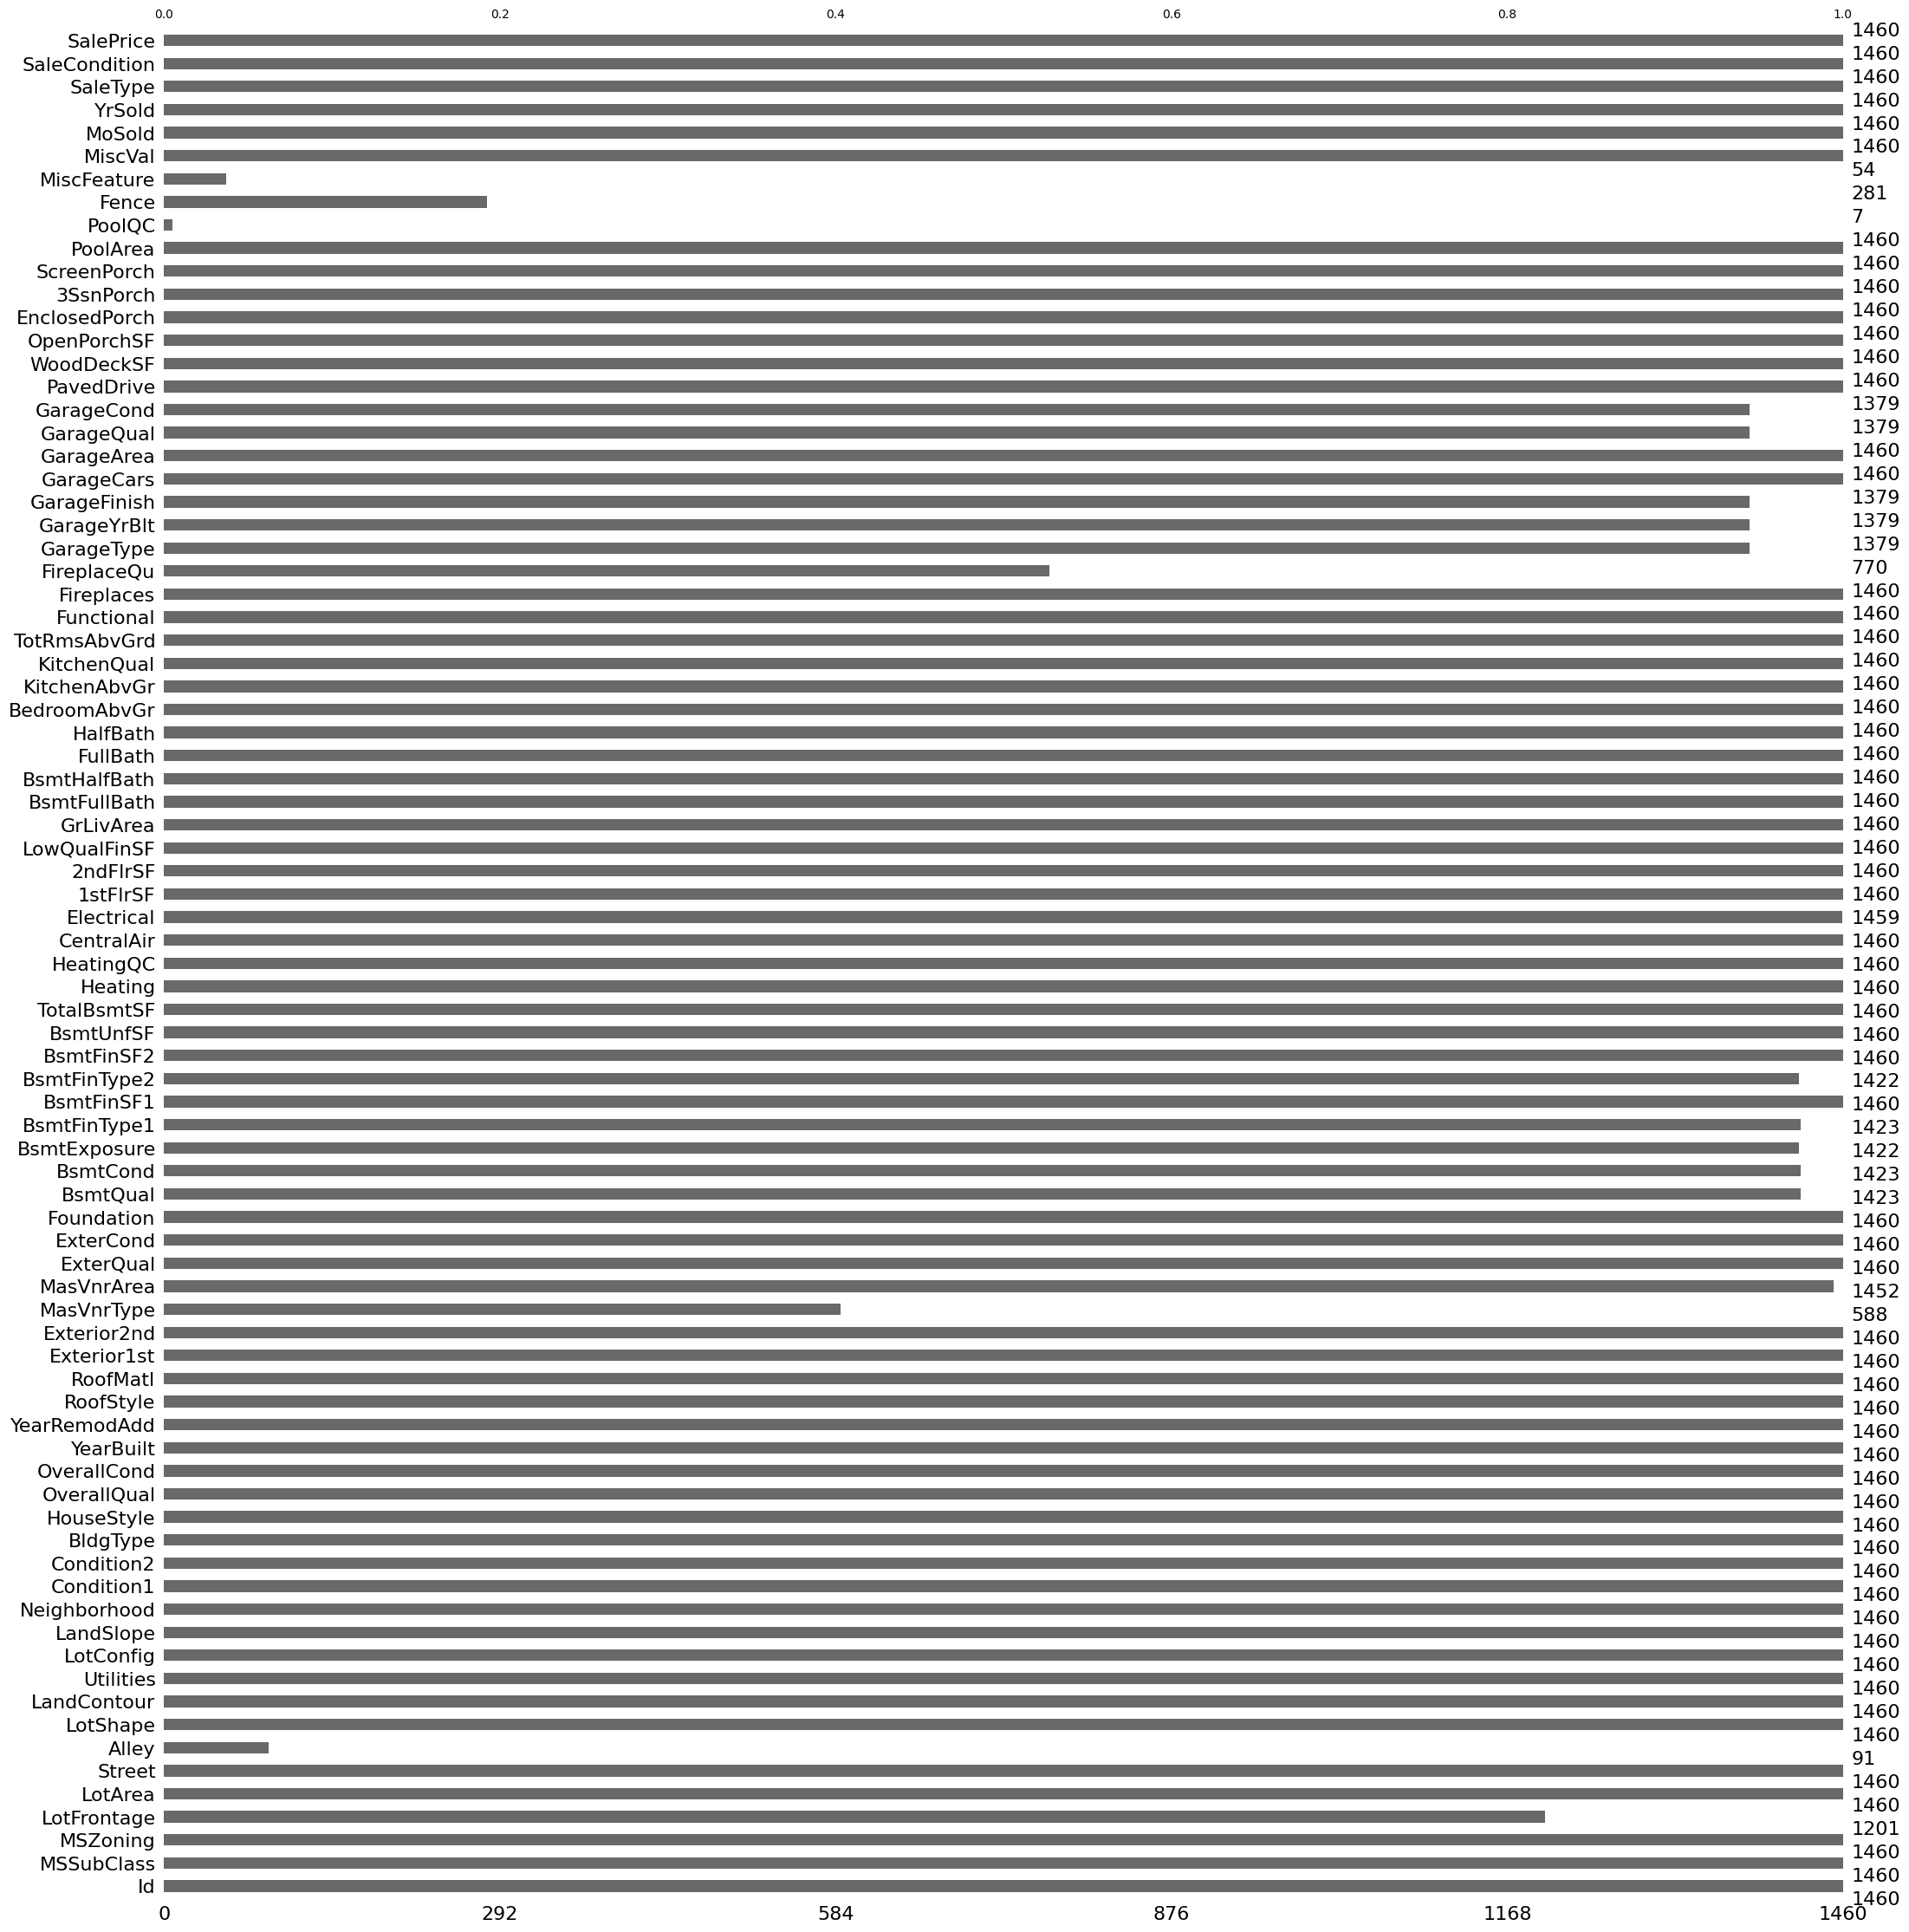

In [10]:
plt.figure(figsize=(12, 6))
msno.bar(df)
plt.show()

# Shows how much data is missing column-wise
# long-bars = complete data
# short-bars = lots of missing values

<Figure size 1200x600 with 0 Axes>

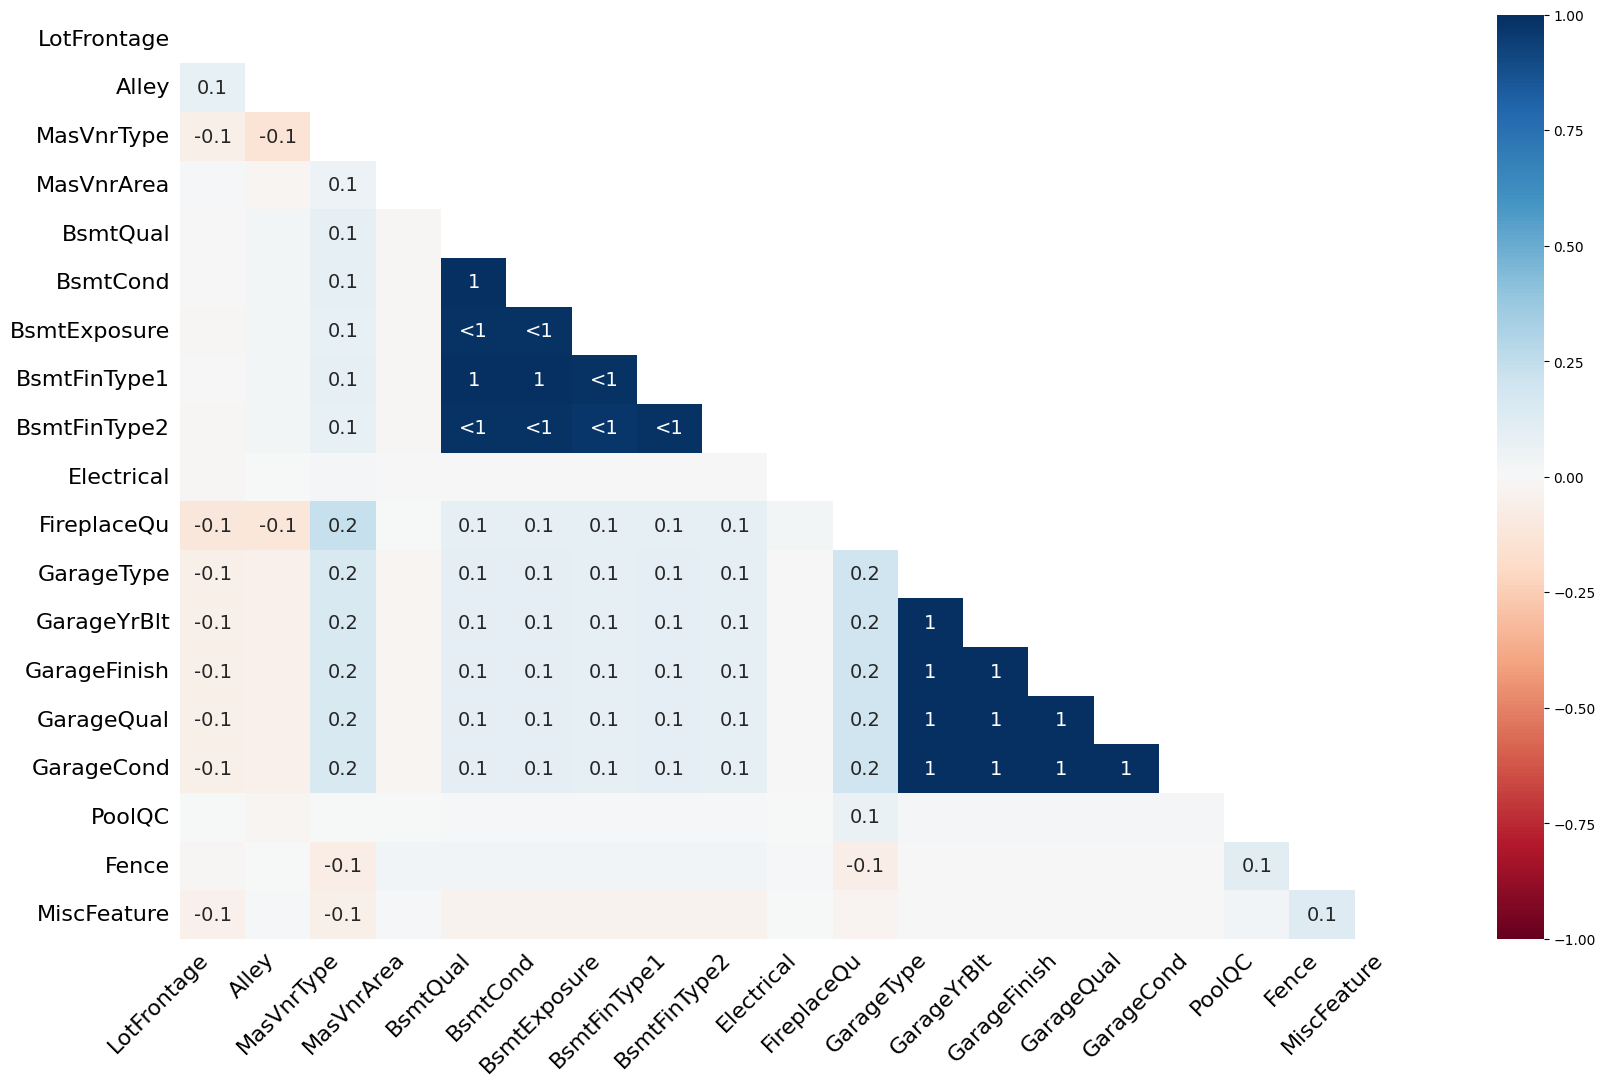

In [11]:
plt.figure(figsize=(12, 6))
msno.heatmap(df)
plt.show()

# values close to 1 = two columns tend to be missing together - present, marks
# values close to 0 = no relationship
# values negative = if one missing, the other is usually present - name, present

# class-test [name, present, marks]

# Case 1 : If person is not present, will they have their name in register ? 
# - negative case, large negative value - (name, present), (name, marks)

# Case 2 : If person is present, will they have score in the marksheet?
# - Absent, they will not have score (present, marks)



# Step 2 - Deletion method

In [12]:
# listwise deletion (Case deletion)
df_listwise = df.dropna()
print("Original Shape : ", df.shape)
print("After listwise deletion Shape : ", df_listwise.shape)

Original Shape :  (1460, 81)
After listwise deletion Shape :  (0, 81)


# Step 3 - Simple Imputation

Instead of deleting, we fill missing values with estimates.

In [13]:
# Function to check before and after of imputation

def compare_imputation(df_before, df_after, column_name):
    missing_indices = {column_name : df_before[df_before[column_name].isnull()].index.to_list() for column_name in df_before.columns if df_before[column_name].isnull().any()}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before" : df_before.loc[idx_list,column_name], 
        "After" : df_after.loc[idx_list,column_name], 
    })

    print(f"Changes in column : {column_name}")
    return comparison



In [14]:
# (a) Mean inputation (numerical Data)

df_mean = df.copy()
df_mean['LotFrontage'].fillna(df_mean['LotFrontage'].mean(), inplace=True)

C:\Users\scl\AppData\Local\Temp\ipykernel_13720\398266078.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean['LotFrontage'].fillna(df_mean['LotFrontage'].mean(), inplace=True)


In [15]:
df_mean = df.copy()
df_mean.fillna({'LotFrontage': df_mean['LotFrontage'].mean()}, inplace=True)

In [16]:
compare_imputation(df, df_mean, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,70.049958
12,NaN,70.049958
14,NaN,70.049958
16,NaN,70.049958
24,NaN,70.049958
31,NaN,70.049958
42,NaN,70.049958
43,NaN,70.049958
50,NaN,70.049958
64,NaN,70.049958


In [17]:
# Issue with using mean : 
# it will pull the distribution towards mean
# underestimate spread

In [18]:
# (b) median imputation (numerical data)
# house - 500K, 750K, 400K, 10M

df_median = df.copy()
df_median.fillna({'LotFrontage': df_median['LotFrontage'].median()}, inplace=True)

In [19]:
compare_imputation(df, df_median, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,69.0
12,NaN,69.0
14,NaN,69.0
16,NaN,69.0
24,NaN,69.0
31,NaN,69.0
42,NaN,69.0
43,NaN,69.0
50,NaN,69.0
64,NaN,69.0


In [20]:
# (c) mode imputation (cetogorial data)
# house - 90% of the house are in URBAN area, 10%

In [21]:
df['GarageType'].unique()

array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

In [22]:
df_mode = df.copy()
df_mode.fillna({'GarageType': df_mode['GarageType'].mode()[0]}, inplace=True)

In [23]:
df_mode['GarageType'].mode()[0]

'Attchd'

In [24]:
compare_imputation(df, df_mode, "GarageType").head(10)

Changes in column : GarageType


,Before,After
39,NaN,Attchd
48,NaN,Attchd
78,NaN,Attchd
88,NaN,Attchd
89,NaN,Attchd
99,NaN,Attchd
108,NaN,Attchd
125,NaN,Attchd
127,NaN,Attchd
140,NaN,Attchd


In [25]:
import seaborn as sns

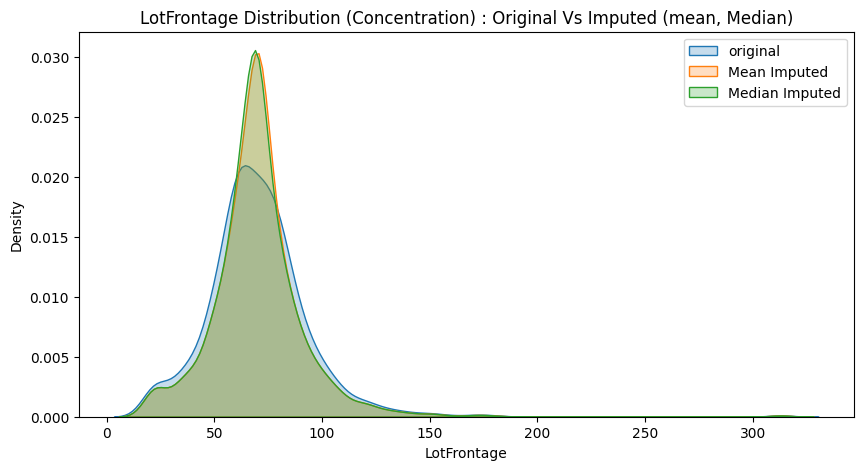

In [26]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['LotFrontage'], label="original", fill=True)
sns.kdeplot(df_mean['LotFrontage'], label="Mean Imputed", fill=True)
sns.kdeplot(df_median['LotFrontage'], label="Median Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution (Concentration) : Original Vs Imputed (mean, Median)")
plt.show()

In [27]:
# Is density interpreted as probability here? NO, they are not equal : PDF, PMF, CDF

# Step 4 : KNN Imputation

In [28]:
# !pip install scikit-learn

In [29]:
from sklearn.impute import KNNImputer

In [30]:
knn_inputer = KNNImputer(n_neighbors=5)

In [31]:
df_knn = df.copy()
columns = ['LotFrontage', 'LotArea', 'YearBuilt']
df_knn[columns] = knn_inputer.fit_transform(df_knn[columns])

In [32]:
compare_imputation(df, df_knn, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,80.2
12,NaN,86.8
14,NaN,67.0
16,NaN,75.4
24,NaN,60.2
31,NaN,66.4
42,NaN,83.6
43,NaN,75.8
50,NaN,96.2
64,NaN,80.2


In [33]:
df_knn_2 = df.copy()
numeric_cols = df_knn_2.select_dtypes(include=[np.number]).columns
df_knn_2[numeric_cols] = knn_inputer.fit_transform(df_knn_2[numeric_cols])

In [34]:
compare_imputation(df, df_knn_2, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,75.6
12,NaN,76.6
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0
31,NaN,67.6
42,NaN,77.0
43,NaN,63.0
50,NaN,68.6
64,NaN,76.4


## Step 5 - Regression Imputation (Advanced)

In [95]:
from sklearn.linear_model import LinearRegression

In [ ]:
df_reg = df.copy()
train_data = df_reg.dropna(subset=['LotFrontage'])
test_data = df_reg[df_reg["LotFrontage"].isnull()]

In [ ]:
X_train = train_data[["LotArea", "OverallQual", "OverallCond"]]
y_train = train_data["LotFrontage"]

# we want "LotArea", "OverallQual", "OverallCond" columns to decide the value of LotFrontage

In [99]:
reg = LinearRegression()
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [101]:
df_reg.loc[df_reg["LotFrontage"].isnull(), "LotFrontage"] = reg.predict(test_data[["LotArea", "OverallQual", "OverallCond"]])

In [103]:
compare_imputation(df, df_reg, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,73.015238
12,NaN,70.063978
14,NaN,71.120296
16,NaN,70.526948
24,NaN,63.397097
31,NaN,64.735937
42,NaN,65.011931
43,NaN,65.525990
50,NaN,74.181950
64,NaN,72.292430


# 2. Handling Outliers
1. data tht are diff from most of other datas called outliers it shifts the mean 
2. why we need to handel outliers ?? Some models are sensitive to extreme value outlier may disords the  points like in the graph shown

In [37]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [35]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


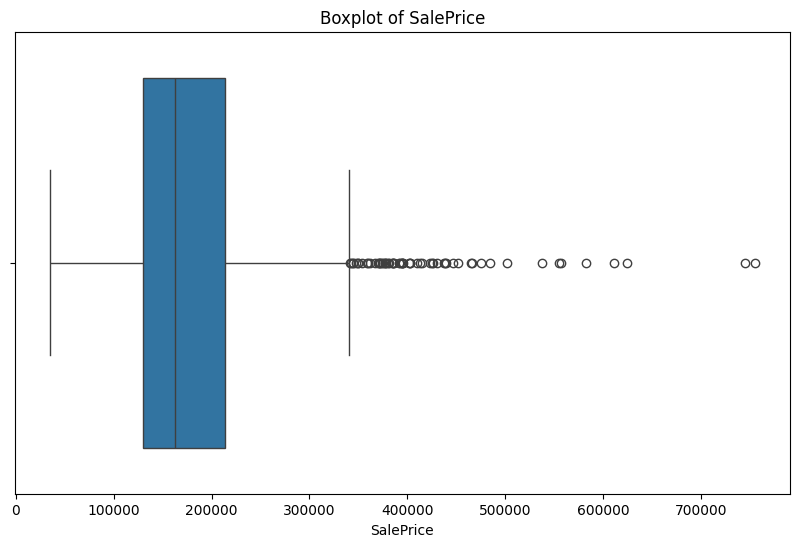

In [ ]:
# 1. Visualization outliers

# Boxplot

plt.figure(figsize=(10,6))
sns.boxplot(x=df['SalePrice'])
plt.title("Boxplot of SalePrice")
plt.show()

# left side of  blue box start is lower Q1
# right side of blue box end is upper Q3
# line between blue box is median
# left whisker = Q1 - 1.5*IQR
# right whisker = Q3 + 1.5*IQR


In [39]:
# IQR

import numpy as np

Bilkul, Pritam! Let's break this down step-by-step in Hinglish so it's crystal clear 👇

---

### 📊 What This Function Does

`detect_outliers_iqr(data, col)` is a Python function that **detects outliers** in a specific column of a DataFrame using the **IQR method** (Interquartile Range).

---

### 🧠 Concept Behind IQR

- **Q1 (25th percentile)**: Value below which 25% of the data lies.
- **Q3 (75th percentile)**: Value below which 75% of the data lies.
- **IQR = Q3 - Q1**: This is the middle 50% spread of the data.

---

### 🚨 Outlier Detection Logic

Outliers are values that fall **far outside the typical range**. We define this range using:

- **Lower bound**: `Q1 - 1.5 * IQR`
- **Upper bound**: `Q3 + 1.5 * IQR`

Any value **less than the lower bound** or **greater than the upper bound** is considered an outlier.

---

### 🧮 Why 1.5 × IQR?

This is a **standard rule of thumb** in statistics:

- 1.5 × IQR is used to define a "reasonable" spread beyond the central 50% of the data.
- It helps **exclude extreme values** without being too aggressive.
- You can tweak this multiplier (e.g., use 3 × IQR for more leniency), but 1.5 is common.

---

### 🔍 Line-by-Line Breakdown

```python
Q1 = data[col].quantile(0.25)      # 25th percentile
Q3 = data[col].quantile(0.75)      # 75th percentile
IQR = Q3 - Q1                      # Interquartile Range
lower = Q1 - 1.5 * IQR             # Lower threshold for outliers
higher = Q3 + 1.5 * IQR            # Upper threshold for outliers
outliers = data[(data[col] < lower) | (data[col] > higher)]  # Filter outliers
return lower, higher, outliers[[col]]  # Return thresholds and outlier values
```

---

### 🧠 Example

Suppose your column has values: `[10, 12, 13, 14, 15, 16, 100]`

- Q1 = 12.5, Q3 = 15.5 → IQR = 3
- Lower = 12.5 - 1.5×3 = 8
- Upper = 15.5 + 1.5×3 = 20

So, `100` is an outlier because it's > 20.
Great question, Pritam! Let’s break down how **Q1** and **Q3** are calculated in simple Hinglish with a hands-on mindset 👇

---

### 📌 What Are Q1 and Q3?

- **Q1 (First Quartile)**: 25% of the data lies **below** this value.
- **Q3 (Third Quartile)**: 75% of the data lies **below** this value.

They help us understand the **spread** and **central tendency** of the data.

---

### 🧮 How Are They Calculated?

Python makes it easy using `pandas`:

```python
Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
```

But let’s understand the **manual logic** behind it:

#### Step-by-Step:

1. **Sort the column values** in ascending order.
2. **Find Q1**:
   - It’s the value at the 25th percentile.
   - If you have `n` values, Q1 is roughly at position `0.25 × (n + 1)`
3. **Find Q3**:
   - It’s the value at the 75th percentile.
   - Position = `0.75 × (n + 1)`
4. If the position is not a whole number, you **interpolate** (take average between two values).

---

### 🧠 Example

Suppose your column has:  
`[5, 7, 8, 12, 13, 14, 18, 21, 23]` → 9 values

- Q1 position = 0.25 × (9 + 1) = 2.5 → average of 2nd and 3rd values → (7 + 8)/2 = **7.5**
- Q3 position = 0.75 × (9 + 1) = 7.5 → average of 7th and 8th values → (18 + 21)/2 = **19.5**

So:
- **Q1 = 7.5**
- **Q3 = 19.5**
- **IQR = Q3 - Q1 = 12**

---



In [ ]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    higher = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > higher)]
    return lower, higher, outliers[[col]]
    
    # IF COLUMN HAS 20% OF OUTLIERS THEN PRINT THE NAME OF THE COLUMN

In [72]:
lower, higher, outliers_saleprice = detect_outliers_iqr(df, "SalePrice")

In [73]:
df.shape[0]

1460

In [46]:
len(outliers_saleprice)
print(outliers_saleprice.min())
print(outliers_saleprice.max())

SalePrice    341000
dtype: int64
SalePrice    755000
dtype: int64


In [66]:
# Z-score

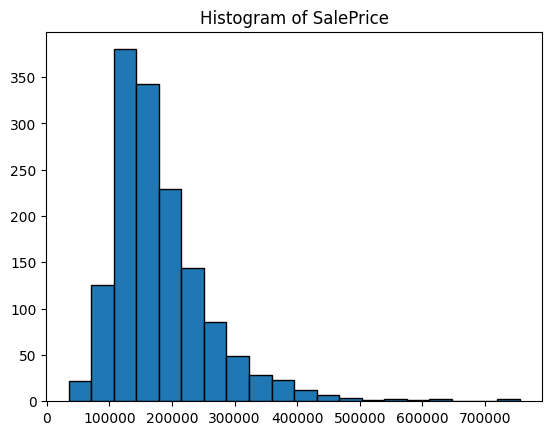

In [ ]:
plt.hist(df['SalePrice'], bins=20, edgecolor='black')
plt.title("Histogram of SalePrice")
plt.show()
'''
### 📊 Why Use a Histogram Even I   f Data Has Outliers?

A **histogram** is a powerful tool to **visualize the distribution** of your data — even when outliers are present.

#### ✅ Here's Why It's Still Useful:

1. **Gives Overall Shape**:
   - You can see if the data is **normal**, **skewed**, **bimodal**, etc.
   - Outliers might stretch the axis, but the core pattern is still visible.

2. **Reveals Outliers Visually**:
   - Outliers show up as **isolated bars** far from the main cluster.
   - This helps you **spot them quickly** and decide if they need handling.

3. **Helps in Preprocessing**:
   - Before applying statistical methods or machine learning, histograms help you decide:
     - Should I remove outliers?
     - Should I transform the data (e.g., log scale)?

4. **Supports Decision-Making**:
   - You can compare histograms **before and after** outlier removal.
   - This shows how much they affect the distribution.

---

### ⚠️ But Be Careful

- Outliers can **distort the scale**, making the main data look compressed.
- In such cases, you can:
  - Use **zoomed-in histograms**
  - Try **log transformation**
  - Plot **boxplots** alongside for clarity

---

### 🧠 Example

Suppose your data has values mostly between 10–50, but a few values like 200 or 300.

- Histogram will show a big cluster near 10–50.
- Then a few tiny bars far away — those are your outliers.

---

Want to try plotting one with your dataset? I can help you write a quick Python snippet using `matplotlib` or `seaborn`. Just say the word!

'''

In [75]:
import scipy.stats as stats

In [ ]:
stats.probplot(df['SalePrice'], dist="norm", plot=plt)
plt.show()

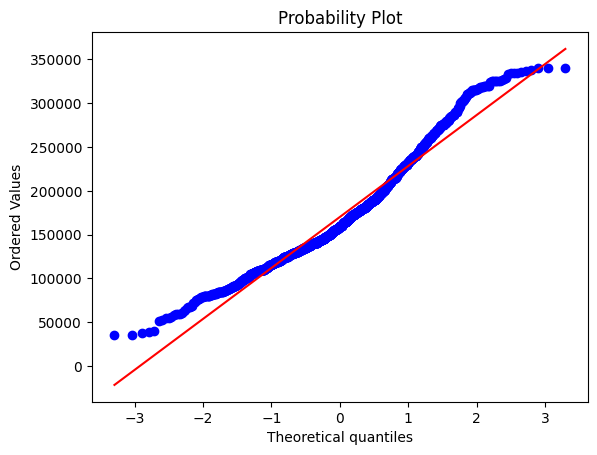

In [79]:
# After removing outliers
df_temp = df.copy()
df_final = df_temp[(df_temp['SalePrice'] >= lower) & (df_temp['SalePrice'] <= higher)]

stats.probplot(df_final['SalePrice'], dist="norm", plot=plt)
plt.show()

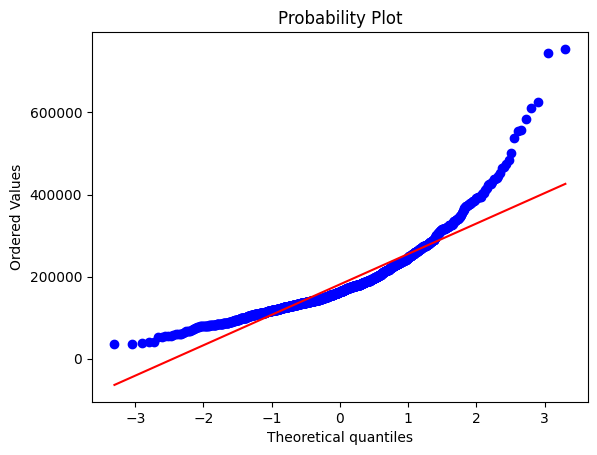

In [ ]:


# how many SD away a value is
# 68% (1)
# 95% (2)
# 99% (two tailed) : 2.58
# 99.7% (two tailed) : 3
# |z| > 3
'''
**In statistics, a Z-distribution (or standard normal distribution) is a special type of normal distribution with a mean of 0 and a standard deviation of 1. It’s used to understand how far a data point is from the average in terms of standard deviations.**

---

### 📊 Z-Distribution Explained

The **Z-distribution** is a **bell-shaped curve** that represents the distribution of standardized data. It’s also called the **standard normal distribution** because:

- **Mean (μ)** = 0  
- **Standard Deviation (σ)** = 1

This makes it easy to compare different datasets by converting raw scores into **z-scores**.

---

### 🧮 What Is a Z-Score?

A **z-score** tells you **how many standard deviations** a data point is from the mean:

\[
z = \frac{x - \mu}{\sigma}
\]

- If \( z = 0 \): the value is exactly at the mean.
- If \( z = +2 \): the value is 2 SDs above the mean.
- If \( z = -1.5 \): the value is 1.5 SDs below the mean.

This helps in identifying **outliers**, comparing scores across distributions, and calculating **probabilities**.

---

### 🎯 Why Use Z-Distribution?

- **Standardization**: Makes different datasets comparable.
- **Probability Calculations**: Helps find the likelihood of a value occurring.
- **Outlier Detection**: Values with \(|z| > 3\) are considered extreme.
- **Confidence Intervals**: Used in hypothesis testing (e.g., 95% confidence → z ≈ ±1.96).

---

### 📌 Real-Life Example

Suppose the average test score is 70 with a standard deviation of 10. If a student scores 85:

\[
z = \frac{85 - 70}{10} = 1.5
\]

This means the student scored **1.5 SDs above the average**.

---

For more details, you can check [GeeksforGeeks](https://www.geeksforgeeks.org/data-science/z-score-in-statistics/) or [Statistics How To](https://www.statisticshowto.com/probability-and-statistics/z-score/). Let me know if you want to try z-score calculations on your own data!

### 📐 Z-Distribution Basics

A **Z-distribution** (aka **standard normal distribution**) is a bell-shaped curve with:

- Mean = 0  
- Standard deviation (SD) = 1

When we say **“how many SDs away a value is”**, we’re talking about its **z-score**:

\[
z = \frac{x - \mu}{\sigma}
\]

Where:
- \(x\) = your value
- \(\mu\) = mean
- \(\sigma\) = standard deviation

---

### 🎯 Fixed Thresholds in Z-Distribution

Yes, these thresholds are **fixed** for a standard normal distribution:

| Confidence Level | Z-Score Range | Coverage |
|------------------|---------------|----------|
| 68%              | ±1 SD         | Most data lies within 1 SD of mean  
| 95%              | ±2 SD         | Covers almost all normal data  
| 99%              | ±2.58 SD      | Very high confidence  
| 99.7%            | ±3 SD         | Extreme confidence  
| \(|z| > 3\)       | Outlier zone  | Rare values beyond 3 SDs  

These are **standard cutoffs** used in statistics and hypothesis testing.

'''

from scipy.stats import zscore


In [ ]:
df["SalePrice_zscore"] = zscore(df["SalePrice"])
outliers_z = df[df["SalePrice_zscore"].abs() > 2]

''''

Perfect, Pritam! You're using **z-score based outlier detection** here. Let me explain this line-by-line in Hinglish 👇

---

### 🧠 What This Code Does

You're calculating how far each value in the `SalePrice` column is from the mean, in terms of **standard deviations (SD)** — and then filtering out values that are **more than 2 SDs away**.

---

### 🔍 Line-by-Line Breakdown

```python
df["SalePrice_zscore"] = zscore(df["SalePrice"])
```

- This line calculates the **z-score** for each value in `SalePrice`.
- Z-score formula:  
  \[
  z = \frac{x - \mu}{\sigma}
  \]
  Where:
  - \(x\) = individual sale price
  - \(\mu\) = mean of sale prices
  - \(\sigma\) = standard deviation of sale prices
- The result tells you **how many SDs away** each value is from the mean.
- You store this in a new column called `"SalePrice_zscore"`.

---

```python
outliers_z = df[df["SalePrice_zscore"].abs() > 2]
```

- This filters rows where the **absolute z-score is greater than 2**.
- That means the value is **more than 2 SDs away** from the mean — either too high or too low.
- These are considered **potential outliers**.

---

### 📌 Why Use Z-Score for Outliers?

- Works well when data is **normally distributed**.
- Helps detect **extreme values** that deviate from the average.
- Thresholds like `|z| > 2` or `|z| > 3` are commonly used:
  - `|z| > 2` → moderately extreme
  - `|z| > 3` → very rare/extreme

---

### 🧪 Quick Tip

If your data is **not normally distributed**, z-score might not be the best method. In that case, use **IQR-based detection** (which you already know!).

Want to compare z-score vs IQR results on the same dataset? I can help you write that side-by-side!

'''
# 100 points --> ML
# 63 outliers --> 
# 22 outliers --> 

# data --> P1
# data --> p2
# data --> google
# data --> openai

In [69]:
len(outliers_z)

63

In [63]:
outliers_z

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_zscore
11,12,60,RL,85.0,11924,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,7,2006,New,Partial,345000,2.066086
53,54,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,...,NaN,NaN,NaN,0,11,2006,WD,Normal,385000,2.569767
58,59,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,...,NaN,NaN,NaN,0,10,2006,New,Partial,438780,3.246967
112,113,60,RL,77.0,9965,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,10,2007,New,Partial,383970,2.556797
151,152,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,1,2008,New,Partial,372402,2.411133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1353,1354,50,RL,56.0,14720,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,3,2010,WD,Normal,410000,2.884568
1373,1374,20,RL,NaN,11400,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,3,2007,WD,Normal,466500,3.596018
1388,1389,20,RL,42.0,14892,Pave,NaN,IR1,HLS,AllPub,...,NaN,NaN,NaN,0,10,2009,WD,Normal,377500,2.475327
1417,1418,60,RL,NaN,16545,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2009,WD,Normal,340000,2.003126


In [ ]:
# Winsorization (Capping extreme values)
# fold = 0.05 (two-tail)
# Anything below the 5th percentile becomes --> 5th percentile value
# Anything above the 95th percentile becomes --> 95th percentile value
# in previous casesd  we remove the outliers but in winsurization what we does is we put the extreme values to a certain limit
# if  thee are outliers below 5th percentile we put them to 5th percentile value
# if there are outliers above 95th percentile we put them to 95th percentile value

In [81]:
# !pip install feature_engine

In [82]:
from feature_engine.outliers import Winsorizer

In [86]:
col_name = "LotArea"

In [87]:
winsor = Winsorizer(capping_method="quantiles", tail="both", fold=0.05, variables=[col_name])
df_winsor = winsor.fit_transform(df)

In [88]:
print(df.shape)
print(df_winsor.shape)

(1460, 82)
(1460, 82)


In [89]:
percentile_5 = df[col_name].quantile(0.05)
percentile_95 = df[col_name].quantile(0.95)

print(f"5th percentile of {col_name} : {percentile_5}")
print(f"95th percentile of {col_name} : {percentile_95}")

5th percentile of LotArea : 3311.7000000000003
95th percentile of LotArea : 17401.149999999998


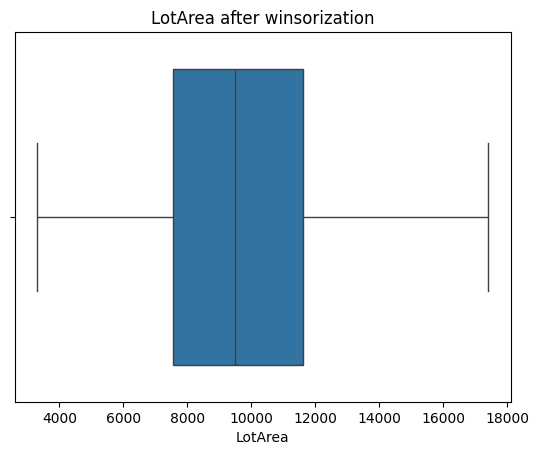

In [90]:
sns.boxplot(x=df_winsor[col_name])
plt.title(f"{col_name} after winsorization")
plt.show()

In [93]:
def compare_outliers(original_df, modified_df, column):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.boxplot(x=original_df[column])
    plt.title(f"{column} - Before")

    plt.subplot(1,2,2)
    sns.boxplot(x=modified_df[column])
    plt.title(f"{column} - After winsorization")

    plt.show()

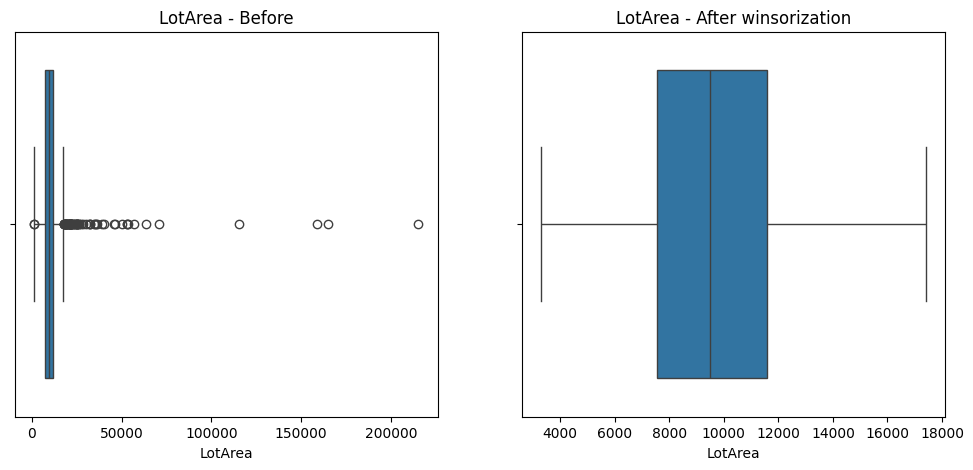

In [94]:
compare_outliers(df, df_winsor, "LotArea")